# Jaguar Re-ID — RNN Improved v1

**Architecture** : Reshape(224, 672) → Bidirectional(LSTM(128)) → Dropout(0.3) → Dense(128) → Dense(31)  
**Improvement over Baseline** : +Bidirectional (lecture haut→bas et bas→haut), +Dropout(0.3), augmentation moderate  
**Diff vs baseline** : Bidirectional LSTM, Dropout 0.3, augmentation none→moderate  
**Note** : Les RNN sont conçus pour des données séquentielles, pas des images. 
Ce notebook mesure combien les améliorations techniques peuvent compenser cette inadéquation structurelle.

## 1. Setup & data loading

In [1]:
import sys, os, glob
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

# GPU setup — LD_LIBRARY_PATH must be set before TF loads CUDA
nvidia_libs = glob.glob(os.path.join(sys.prefix, 'lib/python*/site-packages/nvidia/*/lib'))
if nvidia_libs:
    os.environ['LD_LIBRARY_PATH'] = ':'.join(nvidia_libs) + ':' + os.environ.get('LD_LIBRARY_PATH', '')
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Memory growth — avoid grabbing all VRAM at once (other processes may be running)
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

from src.config import *
from src.data import load_data, load_test_pairs, make_dataset

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU: {gpus}")
if not gpus:
    print("WARNING: No GPU detected, training will be slow on CPU!")
    print("Run this in terminal first: export LD_LIBRARY_PATH=$(python3 -c \"import glob; print(':'.join(glob.glob('env/lib/python*/site-packages/nvidia/*/lib')))\")")
    print("Then restart the Jupyter kernel.")

I0000 00:00:1776164597.182723 1698693 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
MODEL_NAME   = 'rnn_improved_v1'
AUGMENTATION = 'moderate'
#   'none'     → raw images
#   'light'    → flip horizontal
#   'moderate' → flip + brightness + contrast
#   'heavy'    → flip + rotation + zoom + brightness + contrast

In [3]:
X_train, y_train = load_data('train')
X_val, y_val     = load_data('val')
test_pairs_df = load_test_pairs()

train_ds = make_dataset(X_train, y_train, training=True, augmentation=AUGMENTATION)
val_ds   = make_dataset(X_val, y_val)

print(f"Train: {X_train.shape} | Val: {X_val.shape}")
print(f"Train batches: {len(train_ds)} | Val batches: {len(val_ds)}")

I0000 00:00:1776164617.235105 1698693 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 42353 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:86:00.0, compute capability: 8.6
W0000 00:00:1776164617.249068 1698693 cpu_allocator_impl.cc:82] Allocation of 912801792 exceeds 10% of free system memory.
W0000 00:00:1776164618.654253 1698693 cpu_allocator_impl.cc:82] Allocation of 912801792 exceeds 10% of free system memory.


Train: (1516, 224, 224, 3) | Val: (379, 224, 224, 3)
Train batches: 48 | Val batches: 12


## 2. Model architecture

In [4]:
def build_model():
    model = keras.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        # Reshape image (224, 224, 3) → sequence (224, 672)
        layers.Reshape((IMG_SIZE, IMG_SIZE * 3)),

        # Bidirectional LSTM : lecture haut→bas ET bas→haut
        layers.Bidirectional(layers.LSTM(128)),

        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name=MODEL_NAME)
    return model

model = build_model()
model.summary()

Model: "rnn_improved_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 224, 672)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       820,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 31)             │         3,999 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 857,119 (3.27 MB)

 Trainable params: 857,119 (3.27 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Hyperparameter sweep

On teste plusieurs learning rates, on garde le meilleur.

In [5]:
def train_and_eval(lr, run_name):
    m = build_model()
    m.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    log_dir = os.path.join(LOG_DIR, MODEL_NAME, run_name)
    hist = m.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss', patience=10, restore_best_weights=True
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0
            ),
            callbacks.TensorBoard(log_dir=log_dir),
        ],
        verbose=0
    )
    _, val_acc = m.evaluate(val_ds, verbose=0)
    best_epoch = np.argmin(hist.history['val_loss']) + 1
    print(f"  {run_name}: val_acc={val_acc:.4f} (best epoch={best_epoch})")
    return {'val_acc': val_acc, 'best_epoch': best_epoch, 'hist': hist.history}

In [6]:
lr_candidates = [1e-2, 1e-3, 1e-4]

results = {}
print(f"=== LR sweep ({MODEL_NAME}) ===")
for lr in lr_candidates:
    run_name = f'lr_{lr}'
    results[run_name] = train_and_eval(lr, run_name)

=== LR sweep (rnn_improved_v1) ===


W0000 00:00:1776164625.893709 1698693 cpu_allocator_impl.cc:82] Allocation of 912801792 exceeds 10% of free system memory.
I0000 00:00:1776164630.389760 1699051 cuda_dnn.cc:461] Loaded cuDNN version 92000


  lr_0.01: val_acc=0.1266 (best epoch=72)
  lr_0.001: val_acc=0.3061 (best epoch=100)
  lr_0.0001: val_acc=0.5383 (best epoch=100)


In [7]:
rows = [{'Config': name, 'Val Accuracy': r['val_acc'], 'Best Epoch': r['best_epoch']}
        for name, r in results.items()]
results_df = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

BEST_CONFIG = results_df.iloc[0]['Config']
BEST_LR = float(BEST_CONFIG.split('_')[1])
BEST_EPOCH = int(results_df.iloc[0]['Best Epoch'])
print(f"\nBest: {BEST_CONFIG} \u2192 val_acc={results_df.iloc[0]['Val Accuracy']:.4f}")

,Config,Val Accuracy,Best Epoch
0,lr_0.0001,0.538259,100
1,lr_0.001,0.306069,100
2,lr_0.01,0.126649,72



Best: lr_0.0001 → val_acc=0.5383


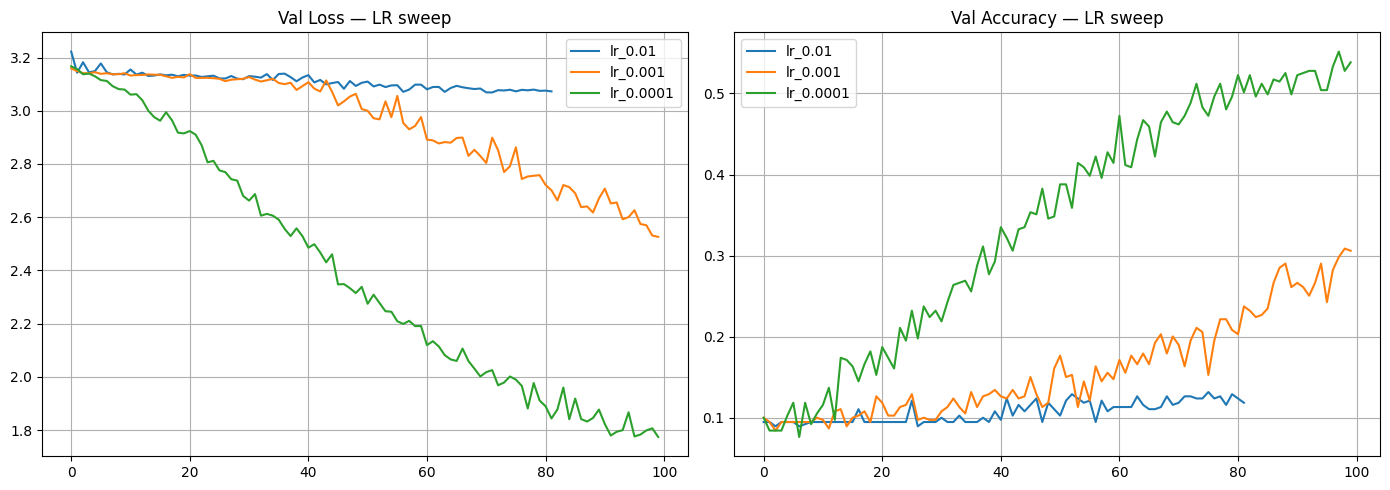

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, r in results.items():
    axes[0].plot(r['hist']['val_loss'],     label=name)
    axes[1].plot(r['hist']['val_accuracy'], label=name)
axes[0].set_title('Val Loss \u2014 LR sweep'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val Accuracy \u2014 LR sweep'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_lr_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Evaluation (best config)

In [9]:
model = build_model()
model.compile(
    optimizer=optimizers.Adam(learning_rate=BEST_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
log_dir = os.path.join(LOG_DIR, MODEL_NAME, f'best_{datetime.now().strftime("%Y%m%d-%H%M%S")}')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1),
    ],
    verbose=1
)

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.0871 - loss: 3.2676 - val_accuracy: 0.0897 - val_loss: 3.1503 - learning_rate: 1.0000e-04
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.0910 - loss: 3.1789 - val_accuracy: 0.0950 - val_loss: 3.1309 - learning_rate: 1.0000e-04
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.1042 - loss: 3.1523 - val_accuracy: 0.0950 - val_loss: 3.1139 - learning_rate: 1.0000e-04
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.0891 - loss: 3.1442 - val_accuracy: 0.1055 - val_loss: 3.1246 - learning_rate: 1.0000e-04
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.1009 - loss: 3.1513 - val_accuracy: 0.0897 - val_loss: 3.1090 - learning_rate: 1.0000e-04
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.1022 - loss: 3.1358 - val_accuracy: 0.1082 - val_loss: 3.0846 - learning_rate: 1.0000e-04
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 

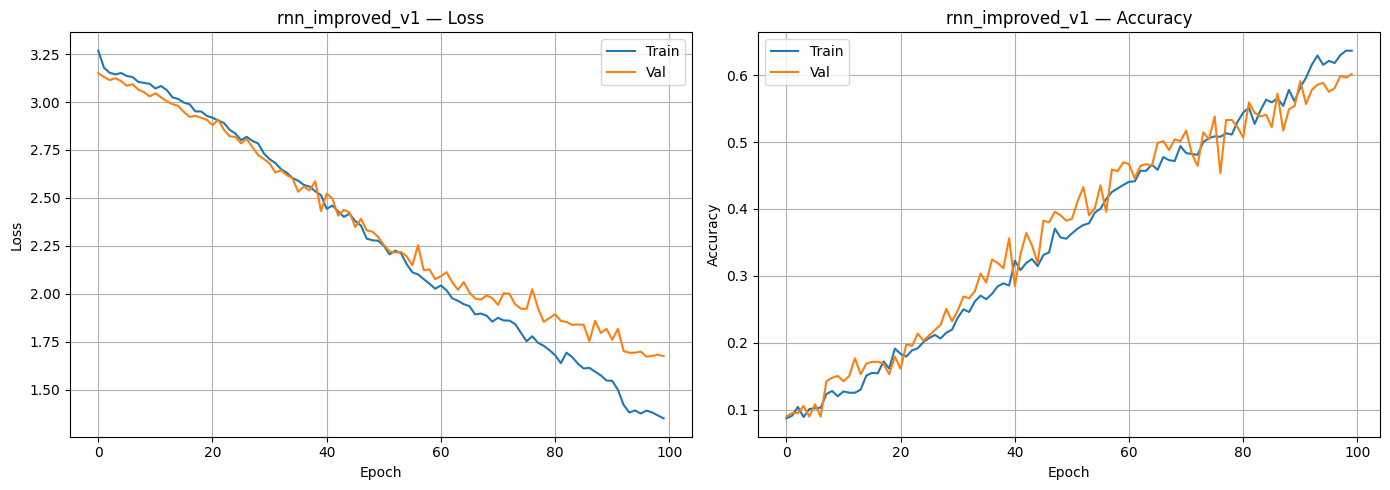

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title(f'{MODEL_NAME} \u2014 Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{MODEL_NAME} \u2014 Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_history.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc     = model.evaluate(val_ds, verbose=0)

print(f"{MODEL_NAME} (best LR={BEST_LR}):")
print(f"  Train \u2014 Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"  Val   \u2014 Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

rnn_improved_v1 (best LR=0.0001):
  Train — Loss: 1.2223, Acc: 0.6840
  Val   — Loss: 1.6726, Acc: 0.5805


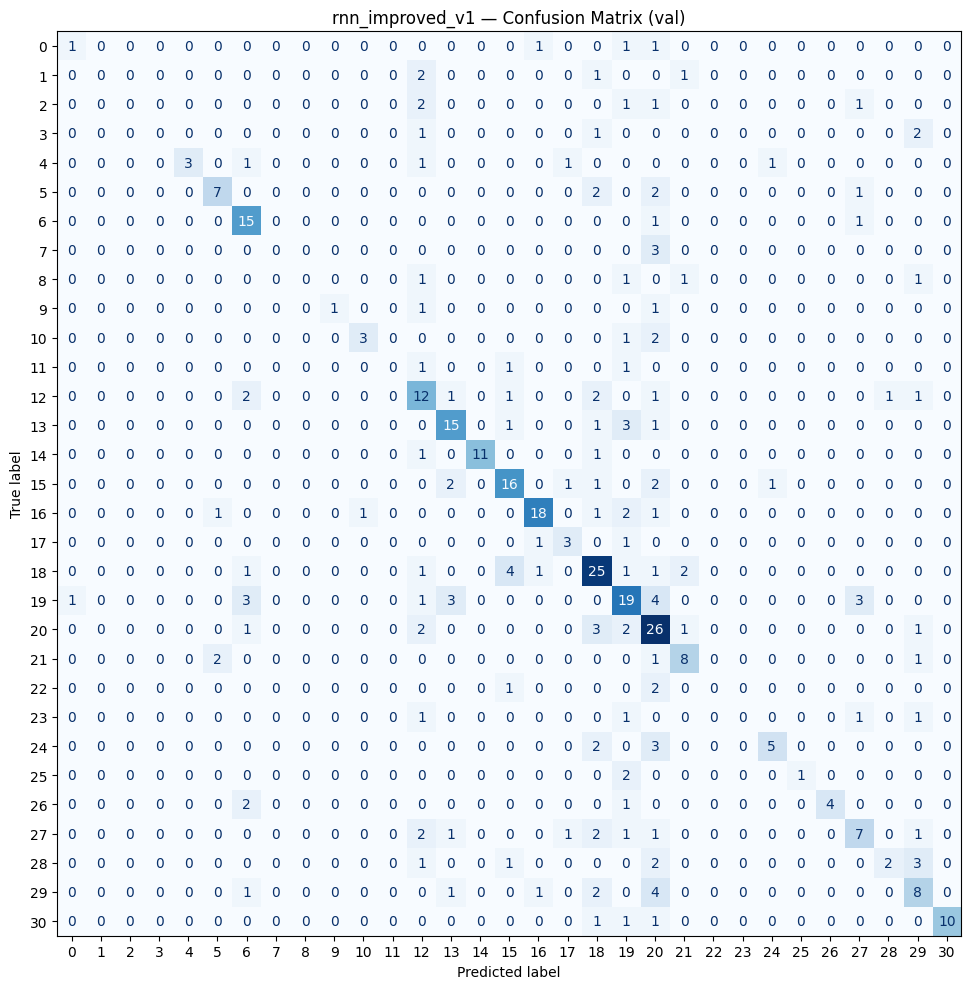

In [12]:
y_val_pred = model.predict(val_ds, verbose=0).argmax(axis=1)

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{MODEL_NAME} \u2014 Confusion Matrix (val)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Kaggle submission

In [13]:
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])
all_ds = make_dataset(X_all, y_all, training=True, augmentation=AUGMENTATION)

print(f"Retraining on full dataset ({len(X_all)} images) for {BEST_EPOCH} epochs")

final_model = build_model()
final_model.compile(
    optimizer=optimizers.Adam(learning_rate=BEST_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_log = os.path.join(LOG_DIR, MODEL_NAME, f'final_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
final_model.fit(
    all_ds, epochs=BEST_EPOCH,
    callbacks=[callbacks.TensorBoard(log_dir=final_log)],
    verbose=1
)
print(f"Final train acc: {final_model.evaluate(all_ds, verbose=0)[1]:.4f}")

W0000 00:00:1776165739.722021 1698693 cpu_allocator_impl.cc:82] Allocation of 1141002240 exceeds 10% of free system memory.
W0000 00:00:1776165741.636878 1698693 cpu_allocator_impl.cc:82] Allocation of 1141002240 exceeds 10% of free system memory.


Retraining on full dataset (1895 images) for 100 epochs
Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.0813 - loss: 3.2843
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.1003 - loss: 3.1902
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.0934 - loss: 3.1637
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.1045 - loss: 3.1579
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.1040 - loss: 3.1375
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.1045 - loss: 3.1264
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.1024 - loss: 3.1298
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.1124 - loss: 3.1108
Epoch 9/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.1230 - loss: 3.1227
Epoch 10/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.1087 - loss: 3.0986
Epoch 11/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.1224 - loss: 3.0

In [14]:
X_test, test_filenames = load_data('test')

inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = inp
for layer in final_model.layers[:-1]:
    x = layer(x)
embedding_model = keras.Model(inputs=inp, outputs=x, name=f'{MODEL_NAME}_embedding')

test_embeddings = embedding_model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embedding shape: {test_embeddings_norm.shape}")

del X_test  # free memory

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}
query_idx   = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

# Chunked to avoid OOM on high-dim embeddings
CHUNK = 1000
similarities = np.empty(len(query_idx), dtype=np.float32)
for start in range(0, len(query_idx), CHUNK):
    sl = slice(start, start + CHUNK)
    q = test_embeddings_norm[query_idx[sl]]
    g = test_embeddings_norm[gallery_idx[sl]]
    similarities[sl] = np.clip((q * g).sum(axis=1), 0, 1)

submission = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
submission_path = os.path.join(SUBMISSION_DIR, f'submission_{MODEL_NAME}.csv')
submission.to_csv(submission_path, index=False)
print(f"Saved: {submission_path}")
display(submission.head())

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
Embedding shape: (371, 128)
Saved: /HomeSweetHome/FHuang5/Developer/kaggle_jaguar_classification/submissions/submission_rnn_improved_v1.csv


,row_id,similarity
0,0,0.656905
1,1,0.564535
2,2,0.855991
3,3,0.711949
4,4,0.728903


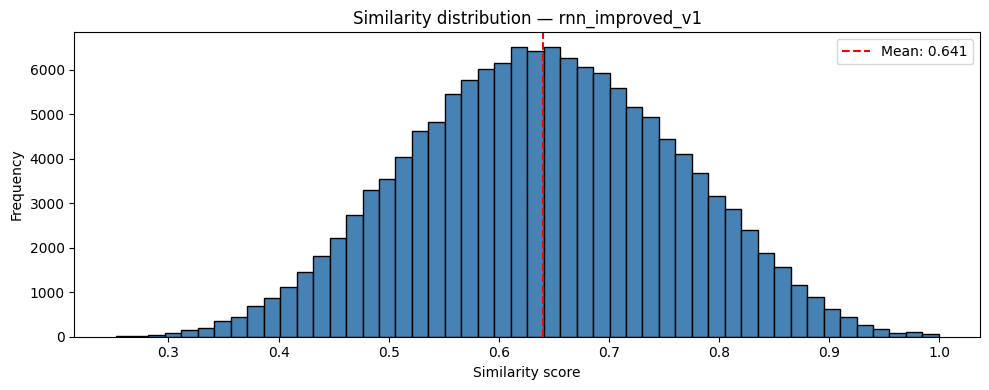

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.axvline(similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.set_xlabel('Similarity score'); ax.set_ylabel('Frequency')
ax.set_title(f'Similarity distribution \u2014 {MODEL_NAME}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_similarity.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Observations & Verdict

### Résultats

| Métrique | Train | Val |
|----------|-------|-----|
| Accuracy | 0.6840 | 0.5805 |
| Loss     | 1.2223 | 1.6726 |
| Overfitting ? | — | Réduit : gap = 10.4 pts (vs 27.0 baseline) |
| Kaggle Score (public) | — | 0.195 |
| Kaggle Score (private) | — | 0.186 |

### Comparaison vs RNN baseline

| Métrique | Baseline | v1 | Diff |
|----------|----------|----|------|
| Params | 430K | 857K | ×2 |
| Sweep best val_acc | 0.6095 | 0.5383 | **−7.1 pts** |
| Section 4 val_acc | 0.6332 | 0.5805 | **−5.3 pts** |
| Section 4 train_acc | 0.9030 | 0.6840 | **−21.9 pts** |
| Gap overfitting | 27.0 pts | 10.4 pts | **−16.6 pts** |
| Final train acc (retrain) | 0.7958 | 0.6501 | −14.6 pts |
| Kaggle public | 0.179 | 0.195 | **+0.016** |
| Kaggle private | 0.151 | 0.186 | **+0.035** |

Résultat paradoxal : la val_acc **baisse** de 5.3 pts mais le Kaggle **monte** de +1.6/+3.5 pts. L'overfitting a été massivement réduit (27 → 10.4 pts) mais au prix d'un **underfitting** — le modèle n'arrive plus à apprendre correctement (train acc 68.4% seulement, vs 90.3% en baseline).

### Analyse des hyperparamètres — modification par modification

#### 1. Bidirectional LSTM — lecture dans les deux sens

Le Bidirectional double le LSTM : un forward LSTM (haut→bas) et un backward LSTM (bas→haut), dont les sorties sont concaténées en un vecteur de 256 dims. Les paramètres passent de 430K à 857K (×2).

**Effet attendu** : ne plus surpondérer les dernières lignes de l'image, capturer des corrélations dans les deux sens de lecture.

**Effet observé** : impossible à isoler car 3 modifications simultanées. Cependant, le Bidirectional a doublé la taille du modèle tout en augmentant la complexité du gradient flow (deux directions × 224 timesteps). Avec lr=0.0001, le modèle plus gros met plus de temps à converger — le sweep atteint seulement 53.8% en 100 epochs (vs 60.9% pour le baseline, même LR, même nombre d'epochs).

**Verdict** : Effet **probablement négatif** dans ce contexte. Le modèle plus gros + régularisation forte = underfitting.

#### 2. Dropout 0.3 — régularisation trop forte pour un modèle déjà faible

Le Dropout 0.3 désactive 30% des 256 neurones de sortie du Bidirectional à chaque forward pass.

**Effet sur l'overfitting** : le gap passe de 27.0 à 10.4 pts — c'est une réduction massive (**−16.6 pts**). Mais le train acc chute de 90.3% à 68.4% : le modèle ne peut plus mémoriser, mais il ne peut plus apprendre non plus. C'est de l'**underfitting** — la régularisation est trop forte pour un modèle qui a déjà du mal à extraire des features utiles d'une séquence de lignes de pixels.

**Comparaison CNN** : en CNN v4, le Dropout 0.5 n'a pas causé d'underfitting car le CNN extrait naturellement de bonnes features grâce à ses convolutions spatiales. Le LSTM n'a pas cette capacité — ajouter du Dropout à un modèle déjà en difficulté aggrave la situation.

**Verdict** : **Trop fort**. Le Dropout réduit l'overfitting mais empêche le LSTM d'apprendre.

#### 3. Augmentation moderate — flip + brightness + contrast

L'augmentation ajoute de la variété aux images d'entraînement. En CNN, elle a prouvé son efficacité (+val_acc). En RNN, elle a un effet supplémentaire négatif : un flip horizontal **inverse l'ordre des pixels dans chaque ligne** (chaque timestep de 672 features est perturbé), et les changements de brightness/contrast modifient les valeurs absolues dont le LSTM dépend fortement (pas de normalisation BatchNorm).

**Verdict** : Effet **probablement négatif** pour le RNN. Le LSTM traite les valeurs brutes des pixels sans normalisation — les perturbations de luminosité/contraste bruitent le signal plus qu'elles ne l'enrichissent.

#### 4. LR sweep — confirmation de la sensibilité RNN

| LR | Baseline val_acc | v1 val_acc | Diff |
|----|-----------|-----------|------|
| 0.01 | 0.0950 | 0.1266 | +3.2 pts |
| 0.001 | 0.4142 | 0.3061 | −10.8 pts |
| 0.0001 | **0.6095** | **0.5383** | −7.1 pts |

Tous les LR sont en baisse (sauf le 0.01 qui reste au hasard). Le lr=0.0001 reste le seul viable mais donne un résultat inférieur. Le modèle plus gros (857K params) avec régularisation a besoin de plus de temps pour converger — les 100 epochs sont peut-être insuffisantes.

#### 5. LR schedule — convergence incomplète

Une seule réduction de LR à epoch 92 (→5e-5). EarlyStopping non déclenché — les 100 epochs sont utilisées intégralement. Le modèle n'a **pas convergé** : la loss continue à baisser doucement. C'est cohérent avec le lr=0.0001 + Dropout + modèle plus gros.

#### 6. Kaggle — paradoxe val_acc ↓ mais Kaggle ↑

Malgré une classification pire (−5.3 pts val_acc), le score Kaggle monte de +1.6/+3.5 pts. C'est le même phénomène observé en CNN (v4 vs v2) : la régularisation produit des embeddings moins spécialisés sur le train set et donc plus transférables pour la cosine similarity. Le Dropout force la couche Dense(128) à distribuer l'information sur plus de dimensions plutôt que de concentrer la décision sur quelques neurones.

Cependant, le gain est modeste (+1.6 pts public) et le score reste très loin du CNN baseline (0.195 vs 0.267).

### Verdict

- [ ] Improvable → Instructions for vN+1
- [x] Not Improvable → **Plafond structurel RNN atteint**
- [ ] Dead-end → On abandonne cette architecture

**Justification — pourquoi on ne peut pas aller plus haut :**

1. **Le modèle est pris entre deux feux** : sans régularisation (baseline), il overfit à 27 pts de gap mais au moins apprend (90% train). Avec régularisation (v1), il n'overfit plus (10 pts) mais n'apprend plus non plus (68% train). Il n'existe pas de point d'équilibre satisfaisant car le problème n'est pas la régularisation — c'est l'architecture.

2. **L'inductive bias est fondamentalement inadapté** : le LSTM cherche des dépendances temporelles entre lignes de pixels. Les motifs discriminants des jaguars (rosettes, taches) sont des structures 2D locales qui ne se manifestent pas comme des patterns séquentiels. Aucune quantité de régularisation, de couches, ou de Bidirectional ne peut compenser cette inadéquation.

3. **Comparaison avec CNN** : le CNN baseline (113K params, aucune régularisation) obtient 0.267 Kaggle. Le RNN v1 (857K params, Dropout + augmentation + Bidirectional) obtient 0.195. **Le CNN le plus simple bat le RNN le plus optimisé**, avec 7.5× moins de paramètres. C'est la preuve que le biais inductif spatial (convolutions) est décisif pour les images.

4. **Rendements décroissants** : le passage de baseline à v1 a coûté 857K params (×2), 3 modifications, et n'a rapporté que +1.6 pts Kaggle. Toute amélioration supplémentaire (stacked LSTM, attention, etc.) apporterait des gains encore plus marginaux.

### Récapitulatif RNN

| Version | Architecture | Régularisation | Kaggle (pub/priv) | Changement clé |
|---------|-------------|---------------|-------------------|---------------|
| Baseline | LSTM(128) | Aucune | 0.179 / 0.151 | — |
| v1 | Bidirectional LSTM(128) | Dropout 0.3, aug moderate | **0.195 / 0.186** | +Bidirectional, +Dropout |

**Comparaison inter-architectures :**

| Architecture | Meilleur Kaggle (pub/priv) | Params |
|-------------|--------------------------|--------|
| Linéaire | 0.165 / — | 4.6M |
| MLP | 0.164 / 0.178 | 38.5M |
| **RNN (best)** | **0.195 / 0.186** | **857K** |
| CNN baseline | 0.267 / 0.264 | 113K |
| CNN v5 (best) | **0.404 / 0.409** | 1.64M |

Le RNN se place entre le MLP et le CNN baseline — il fait mieux que les modèles sans structure (linéaire, MLP) car le LSTM capture au moins des corrélations entre lignes, mais bien pire que les CNN qui exploitent la structure spatiale 2D.

### Interprétation

_Ce notebook conclut l'exploration des RNN sur des images et confirme la thèse du baseline : les RNN sont structurellement inadaptés aux tâches visuelles. Le résultat le plus éloquent est le paradoxe underfitting/overfitting : la baseline overfit sévèrement (27 pts) parce que le LSTM mémorise les séquences de lignes sans comprendre les motifs 2D, et la v1 underfit (68% train) parce que la régularisation empêche cette mémorisation sans offrir d'alternative. Il n'y a pas de juste milieu car le problème est le biais inductif, pas les hyperparamètres. Le classement final Linéaire < MLP < RNN < CNN illustre parfaitement la hiérarchie des biais inductifs pour les images : aucun < non-linéarité < dépendances séquentielles < structure spatiale 2D. Cette hiérarchie est un résultat pédagogique central pour la soutenance._